Columns found in CSV: ['sample_id', 'X1_SoftSeg', 'X2_DA_Content', 'X3_HardSeg', 'X4_R_Ratio', 'X5_Crosslink', 'Iso_Type', 'Hard_Symmetry', 'Polyol_Type', 'Polyol_Mw_Score', 'Soft_Cryst', 'Interact_Cryst_Content', 'Synergy_Feature', 'DA_strategy', 'cross_class', 'poly_tem', 'healing_temperature', 'healing_time', 'strain_rate', 'tensile_strength', 'elongation', 'healing_eff']
Original samples: 91, Cleaned samples: 50


C:\Users\leon\AppData\Local\Temp\ipykernel_178664\995350117.py:49: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = ax_a.scatter(df_clean[col_x], df_clean[col_y],
C:\Users\leon\AppData\Local\Temp\ipykernel_178664\995350117.py:86: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


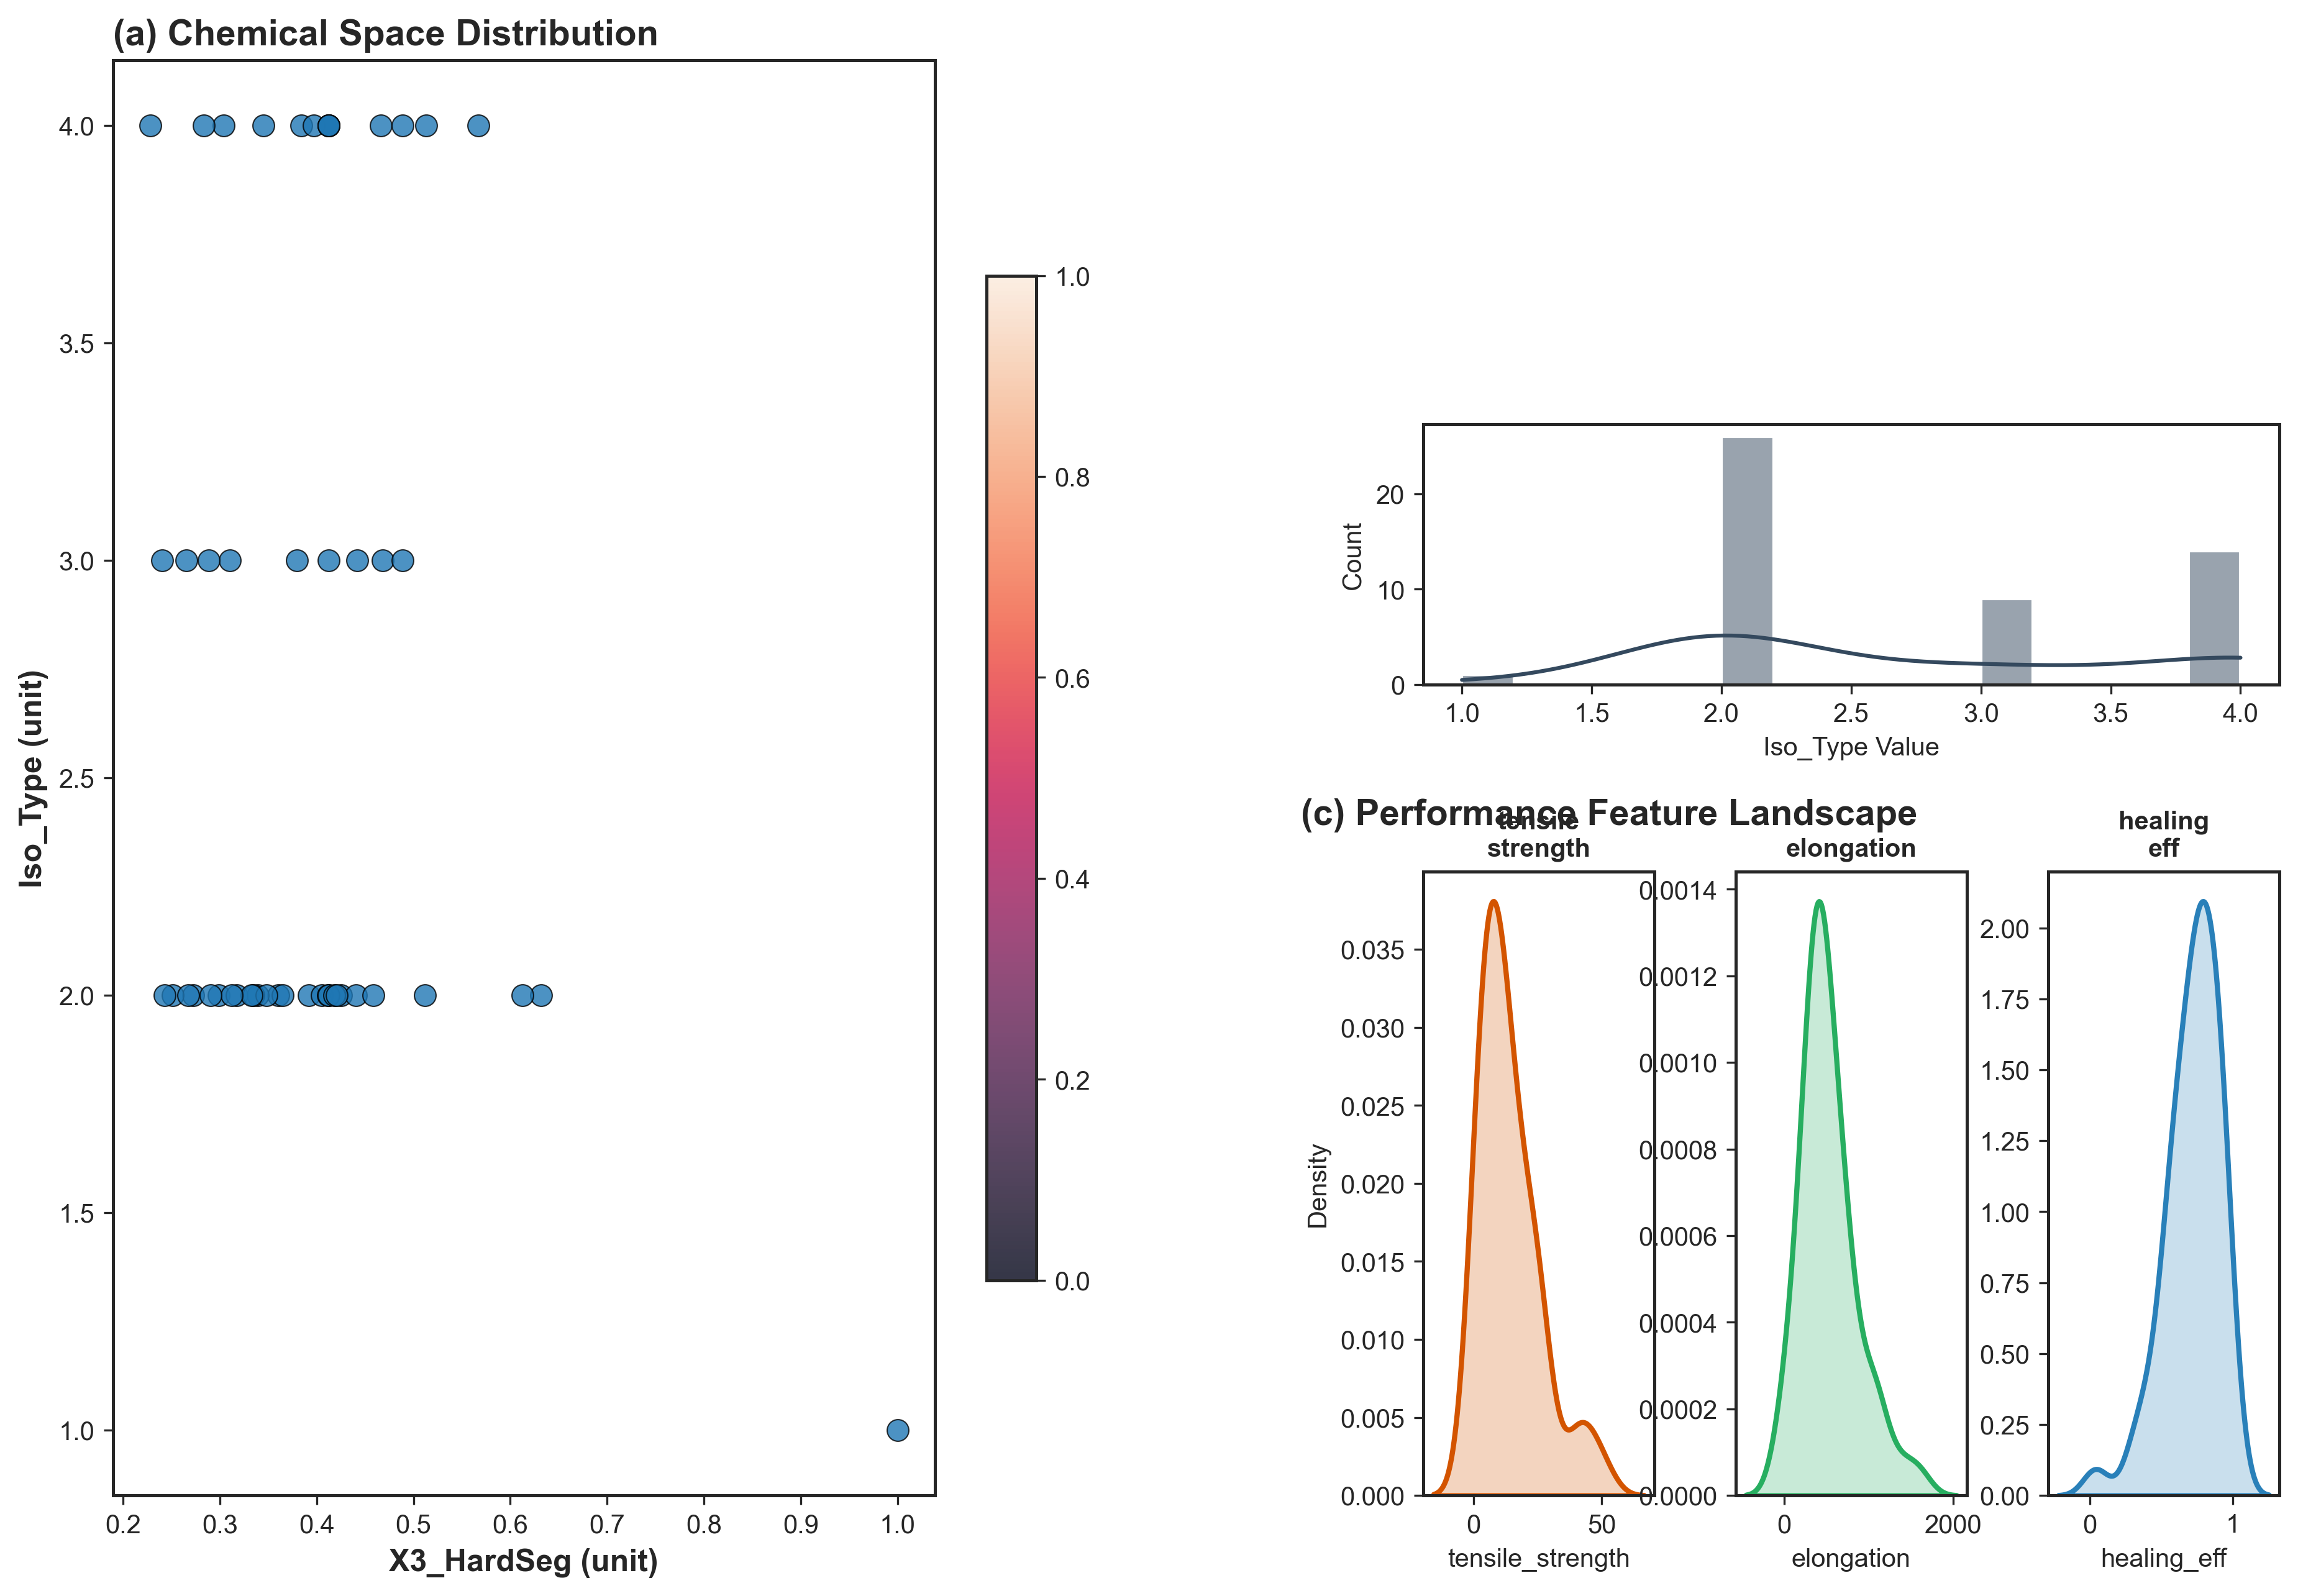

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import numpy as np

# 1. 数据读取与预处理 
try:
    # 读取 CSV 文件
    file_path = "Final_Features_12.20_deletion_tensile.csv" 
    df = pd.read_csv(file_path)
    
    # 打印前五行和列名，方便你检查是否读取正确
    print("Columns found in CSV:", df.columns.tolist())
    
    col_x = 'X3_HardSeg' 
    col_y = 'Iso_Type'
    #col_color = 'Dynamic_Bond'
    #col_cat = 'Polyol_Type'        # 分类变量，用于手风琴图
    metrics = ['tensile_strength', 'elongation', 'healing_eff'] # 性能列
    
    # 数据清洗：剔除绘图所需列中含有空值的行，保证绘图不报错
    plot_cols = [col_x, col_y] + metrics
    df_clean = df[plot_cols].dropna().reset_index(drop=True)
    
    print(f"Original samples: {len(df)}, Cleaned samples: {len(df_clean)}")

except FileNotFoundError:
    print("错误：未找到 CSV 文件，请检查路径。")
    exit()
except KeyError as e:
    print(f"错误：CSV 中缺少列名 {e}，请检查 Header 是否匹配。")
    exit()

# 2. 全局学术风格设置

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.linewidth'] = 1.2
sns.set_style("ticks")


# 3. 布局设计 (a, b, c 三板块)
fig = plt.figure(figsize=(15, 10), dpi=300) # 300dpi 达到出版要求
gs = gridspec.GridSpec(2, 2, width_ratios=[1.2, 1], hspace=0.3, wspace=0.3)

# --- Panel (a): 化学空间投影 ---
ax_a = fig.add_subplot(gs[:, 0])
# 思辨：使用带有边缘颜色的散点，可以有效区分重叠的数据点
scatter = ax_a.scatter(df_clean[col_x], df_clean[col_y], 
                       #c=df_clean[col_color], 
                       cmap='viridis', 
                       s=70, edgecolors='k', linewidth=0.5, alpha=0.8)
ax_a.set_xlabel(f'{col_x} (unit)', fontsize=12, fontweight='bold')
ax_a.set_ylabel(f'{col_y} (unit)', fontsize=12, fontweight='bold')
ax_a.set_title('(a) Chemical Space Distribution', loc='left', fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax_a, shrink=0.7)
#cbar.set_label(f'{col_color}', fontweight='bold')

# --- Panel (b): 目标特征 (soft_Mw) 的统计分布 ---
gs_b = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0, 1], hspace=0.4)

# b-1: 基于分类变量的手风琴图
#ax_b1 = fig.add_subplot(gs_b[0, 0])
#sns.violinplot(x=col_cat, y=col_y, data=df_clean, ax=ax_b1, palette="muted", inner="quartile")
#ax_b1.set_title(f'(b) {col_y} Distribution by {col_cat}', loc='left', fontsize=12, fontweight='bold')

# b-2: 整体分布的直方图+密度曲线
ax_b2 = fig.add_subplot(gs_b[1, 0])
sns.histplot(df_clean[col_y], kde=True, ax=ax_b2, color='#34495e', bins=15)
ax_b2.set_xlabel(f'{col_y} Value')

# --- Panel (c): 性能指标分布 ---
gs_c = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1, 1], wspace=0.35)
colors = ['#d35400', '#27ae60', '#2980b9']

for i, col in enumerate(metrics):
    ax = fig.add_subplot(gs_c[i])
    # 思辨：KDE 图能比直方图更直观地反映出多峰分布（Multimodal Distribution）
    sns.kdeplot(df_clean[col], fill=True, color=colors[i], ax=ax, lw=2)
    ax.set_title(col.replace('_', '\n'), fontsize=10, fontweight='bold')
    ax.set_ylabel('Density' if i == 0 else '')

fig.text(0.55, 0.47, '(c) Performance Feature Landscape', fontsize=14, fontweight='bold')

# 4. 保存与展示
plt.tight_layout()
# plt.savefig('Publication_Quality_Figure.pdf', format='pdf', bbox_inches='tight') # 导出矢量图
plt.show()